## Respiratory illness triage using computer vision

Task: Build a noise resilient model that is able to identify respiratory illnesses using sound.

Procedure:
1. Get the data - Here we have dataset from kaggle [Respiratory sound database](https://www.kaggle.com/datasets/vbookshelf/respiratory-sound-database)
2. Visualize the data - Here we transform the sound into spectograms - a 2D frequency representation of sound
3. Get the model - Since we are working with spectograms(images), we will utilize convulutional neural nets (CNN's) to proceed with the classification task.
4. Test - Test different models, custom made or pretrained models from torch hub

## 2 Visualize the data

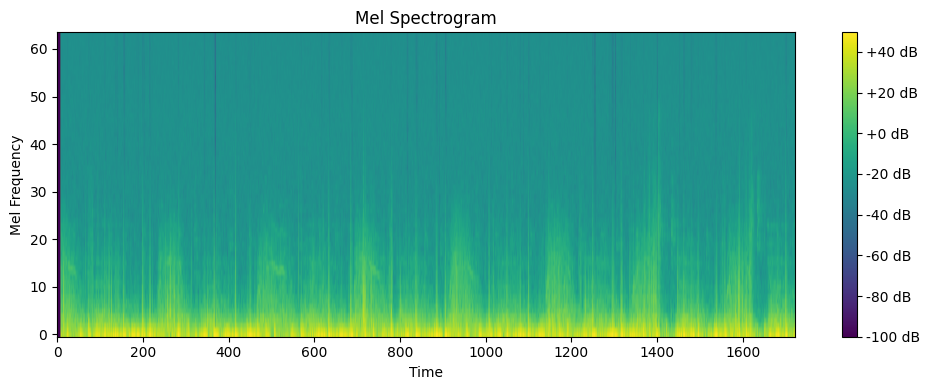

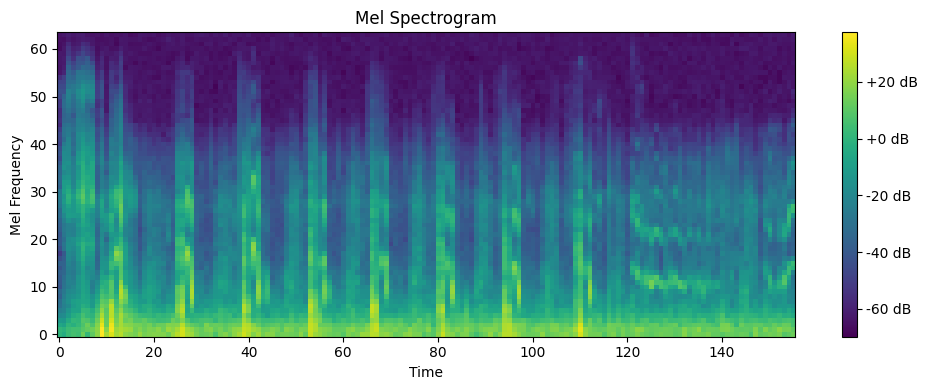

(None, None)

In [7]:
import torch
import numpy as np
import torchaudio
import matplotlib.pyplot as plt
from PIL import Image
import soundfile as sf

SPECTOGRAM_DPI = 90 # Image quality - dots per inch
DEFAULT_SAMPLE_RATE = 16000
DEFAULT_HOP_LENGTH = 512

class audio:
    def __init__(self, filepath_, hop_length = DEFAULT_HOP_LENGTH, samples_rate=DEFAULT_SAMPLE_RATE):
        
        self.hop_length = hop_length
        self.samples_rate = samples_rate
        aud, self.sample_rate = sf.read(filepath_)
        self.waveform = torch.tensor(aud, dtype=torch.float32)
        # if stereo mono
        if self.waveform.ndim > 1:
            self.waveform = self.waveform.mean(dim=1)

        # add channel dimension
        self.waveform = self.waveform.unsqueeze(0)

    
    def plot_spectogram(self):
        mel_spectogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sample_rate,
            n_fft=1024,
            hop_length=self.hop_length,
            n_mels=64
        )
        to_db = torchaudio.transforms.AmplitudeToDB()

        mel_spec = to_db(mel_spectogram(self.waveform))
        plt.figure(figsize=(10, 4))
        plt.imshow(mel_spec[0], origin="lower", aspect="auto")
        plt.colorbar(format="%+2.0f dB")
        plt.title("Mel Spectrogram")
        plt.xlabel("Time")
        plt.ylabel("Mel Frequency")
        plt.tight_layout()
        plt.show()
    
audio_sample = audio("./data/107_2b3_Ar_mc_AKGC417L.wav")
audio_sample2 = audio("./data/109_1b1_Ar_sc_Litt3200.wav")
audio_sample.plot_spectogram(), audio_sample2.plot_spectogram()